In [ ]:
import marimo as mo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

# Q1 Regression with MLE

1. Analytical: Write out a mathematical expression of the maximum likelihood
estimate for the linear regression problem. Write the expression such that
it only depends on the parameters we will estimate in this problem (Note:
in this part of the problem you don’t have actually find the maximum; just
write an expression of the likelihood that you could maximize)

Assuming $y_i = x_i^T w + \epsilon_i$ where $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$, the likelihood is:

$$L(w, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - x_i^T w)^2}{2\sigma^2}\right)$$

2. Computational: Find the MLE of regression coefficients (weights) and fit
them to the training dataset, polynomial train.csv. You can do this
either analytically (i.e., $\hat{w} = (X^T X)^{−1}X^Ty)$ or numerically (i.e., iteratively
minimize the NLL using an optimizer). Show your code. Finally, plot the
predicted values using the MLE estimates on 1) the training data and 2)
the test data.

In [ ]:
# Load data
train = pd.read_csv('data/polynomial_train-1.csv')
x_train, y_train = train['X'].to_numpy(), train['Y'].to_numpy()

test = pd.read_csv('data/polynomial_test-1.csv')
x_test, y_test = test['X'].to_numpy(), test['Y'].to_numpy()

In [ ]:
# Transform data
degree = 6
X_train = np.array([x_train] * degree).T
X_test = np.array([x_test] * degree).T

# Create polynomial variables
for i in range(degree):
    X_train[:,i] = X_train[:,i] ** i
    X_test[:, i] = X_test[:, i] ** i

In [ ]:
# Compute MLE betas
def fit_ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.linalg.inv(X.T @ X) @ (X.T @ y)

betas = fit_ols(X_train, y_train)
y_pred_ols_train = X_train @ betas
y_pred_ols_test = X_test @ betas

# Smooth curve for plotting
x_curve = np.linspace(min(np.min(x_train), np.min(x_test)), max(np.max(x_train), np.max(x_test)), 200)
X_curve = np.column_stack([x_curve**i for i in range(degree)])
y_curve_ols = X_curve @ betas

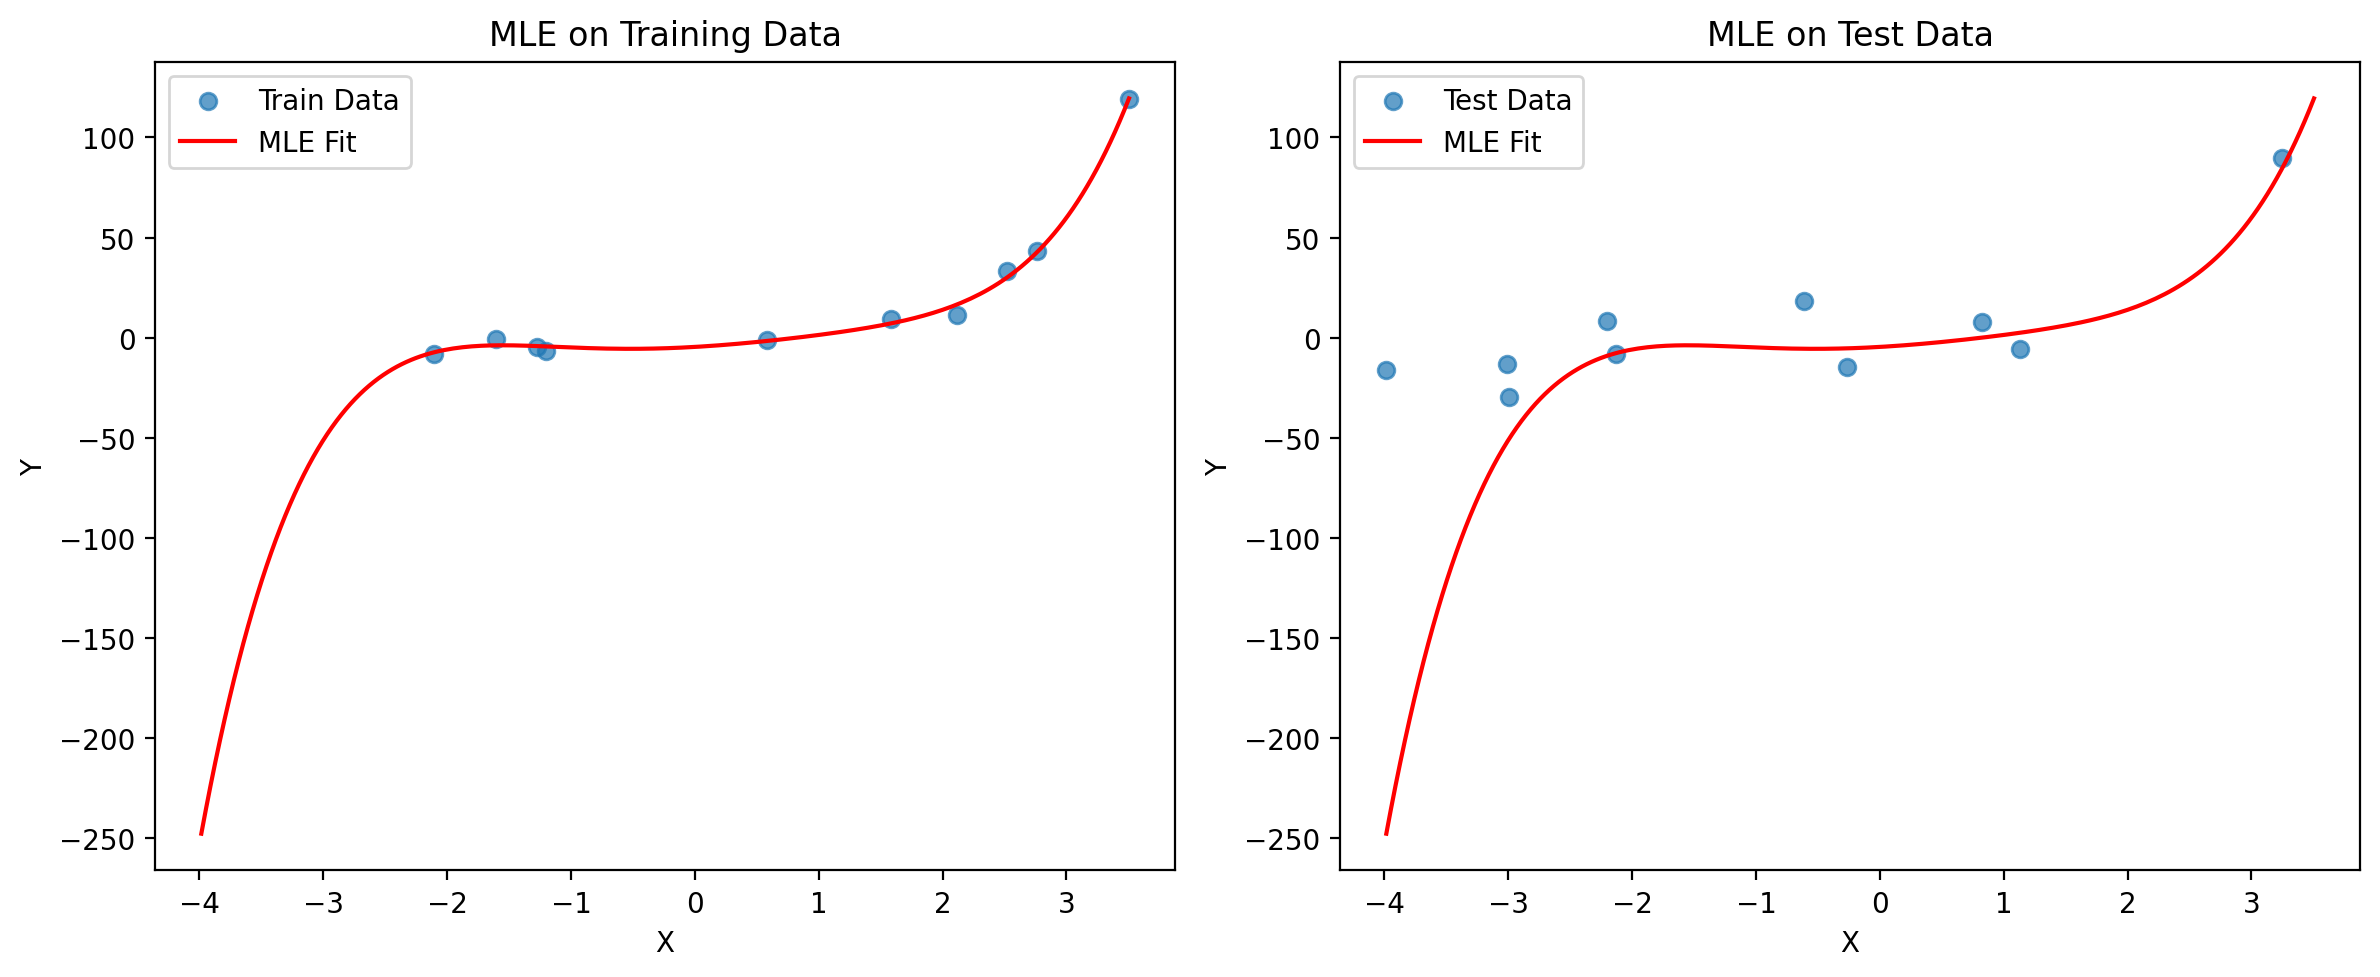

In [ ]:
_, axes_mle = plt.subplots(1, 2, figsize=(12, 5))

axes_mle[0].scatter(x_train, y_train, label="Train Data", alpha=0.7)
axes_mle[0].plot(x_curve, y_curve_ols, color='red', label="MLE Fit")
axes_mle[0].set_xlabel("X")
axes_mle[0].set_ylabel("Y")
axes_mle[0].set_title("MLE on Training Data")
axes_mle[0].legend()

axes_mle[1].scatter(x_test, y_test, label="Test Data", alpha=0.7)
axes_mle[1].plot(x_curve, y_curve_ols, color='red', label="MLE Fit")
axes_mle[1].set_xlabel("X")
axes_mle[1].set_ylabel("Y")
axes_mle[1].set_title("MLE on Test Data")
axes_mle[1].legend()

plt.tight_layout()
plt.show()